In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('repo/PatHoST')

# Library

In [66]:
import src.datasets as datasets
import src.utils as utils
import src.spatial as spatial
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
import anndata as ad
from pathlib import Path
from joblib import dump, load
import warnings
warnings.filterwarnings("ignore")

In [4]:
import torch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Configure Paths

In [6]:
train_path='/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/analysis/'

# Create Spatial data dictionary

In [7]:
spdata={}

## Train slice 1

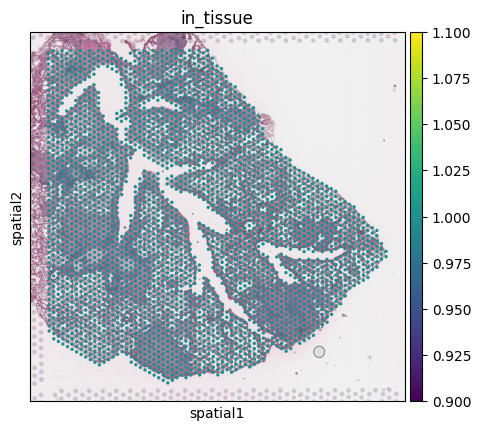

In [8]:
zdata=sc.read_visium(f"{train_path}/V12N16307C1_noair/outs")

sc.pl.spatial(zdata,color='in_tissue')

In [9]:
with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]

cols_to_remove = [zdata.var.index.get_loc(gene) for gene in genes if gene in zdata.var.index]
cols_to_keep = [zdata.var.index.get_loc(gene) for gene in genes if gene in zdata.var.index]
all_cols = np.arange(zdata.X.shape[1])
all_cols = np.delete(all_cols, cols_to_remove)
# Get the indices of columns with at least 1 count
non_zero_cols = np.where(zdata.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep = []
for i in non_zero_cols:
	gene=zdata.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep.append(cols_to_keep[i])

zdata.obs['beads']=(zdata.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5
zdata.obs['beads']=(zdata.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5

In [10]:
spdata['Train_1'] = {}
spdata['Train_1']['dataX'] = zdata
spdata['Train_1']['ycol'] = final_cols_to_keep
spdata['Train_1']['dataY'] = zdata
spdata['Train_1']['xcol'] = all_cols

## Train Slice 2

In [11]:
spot_to_keep=pd.read_csv('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/analysis/subs/A1_6SPA/V13J17-404-A1_6SPA_Parwoairways.json.tab',sep=' ',names=['col','row'])

barcode=pd.read_csv('/idle/ric.cirillo/dimarco.federico/envs/spatial/lib/python/cellranger/barcodes/visium-v2_coordinates.txt',sep='\t',names=['barcode','col','row'])

spot_to_keep=spot_to_keep.merge(barcode,how='inner',on=['col','row'])['barcode']

spot_to_keep=spot_to_keep + '-1'

print(spot_to_keep)

0       GGGAACCACCTGTTTC-1
1       GTTCGTTGCGGACCAG-1
2       TGAGGTTGATCCCAAG-1
3       GATGCCACACTACAGC-1
4       AGGCAAAGAGGAATCA-1
               ...        
3344    GCCCTAAGTGCAGGAT-1
3345    ACTTGGGCTTTCGCCA-1
3346    CATGATACGGTGAAAC-1
3347    TCCTGCAGCCGCCAAT-1
3348    GTCCGTTAGAGGGCCT-1
Name: barcode, Length: 3349, dtype: object


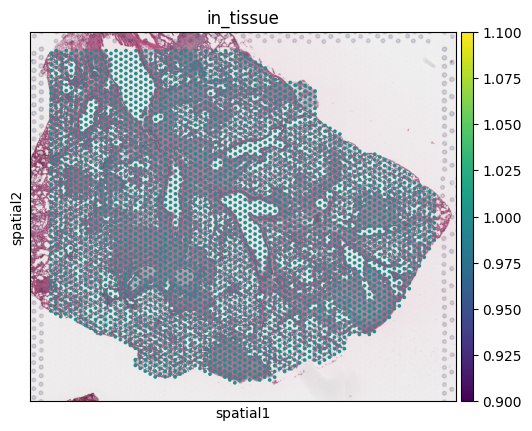

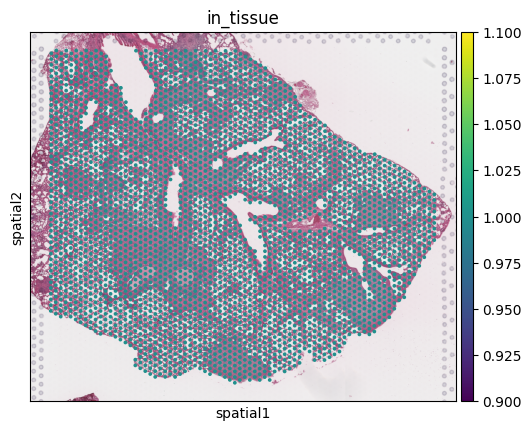

In [12]:
bdata=sc.read_visium(f"{train_path}/A16SPA/outs")
sc.pl.spatial(bdata,color='in_tissue')
bdata_s= bdata[bdata.obs.index.isin(spot_to_keep)]
sc.pl.spatial(bdata_s,color='in_tissue')

with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]


cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]

# Get the indices of columns with at least 1 count
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep_b = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep_b.append(cols_to_keep[i])

In [13]:
with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]

cols_to_remove = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]
cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]
all_cols = np.arange(bdata_s.X.shape[1])
all_cols = np.delete(all_cols, cols_to_remove)
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep.append(cols_to_keep[i])

In [14]:

spdata['Train_2'] = {}
spdata['Train_2']['dataX'] = bdata_s
spdata['Train_2']['ycol'] = final_cols_to_keep
spdata['Train_2']['dataY'] = bdata_s
spdata['Train_2']['xcol'] = all_cols

## Train Slice 3

In [15]:
spot_to_keep=pd.read_csv('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/analysis/subs/C1_6SPAL/V13J17-404_C1_NOairways.png.json.tab',sep=' ',names=['col','row'])

barcode=pd.read_csv('/idle/ric.cirillo/dimarco.federico/envs/spatial/lib/python/cellranger/barcodes/visium-v2_coordinates.txt',sep='\t',names=['barcode','col','row'])

spot_to_keep=spot_to_keep.merge(barcode,how='inner',on=['col','row'])['barcode']

spot_to_keep=spot_to_keep + '-1'

print(spot_to_keep)

0       GTGTGAGCCGAGGTGC-1
1       GGGAACCACCTGTTTC-1
2       GTTCGTTGCGGACCAG-1
3       TGAGGTTGATCCCAAG-1
4       GATGCCACACTACAGC-1
               ...        
3408    AAATGACTGATCAAAC-1
3409    TTCGTGCATGTTATAG-1
3410    ATCAAAGAGCCGTGGT-1
3411    ATGTCATAATAAACGA-1
3412    CTTAATCGACTTAGTA-1
Name: barcode, Length: 3413, dtype: object


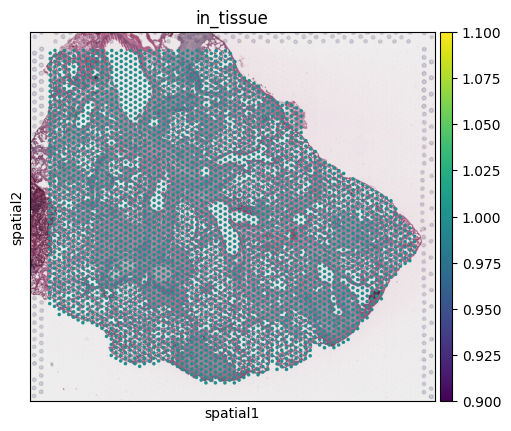

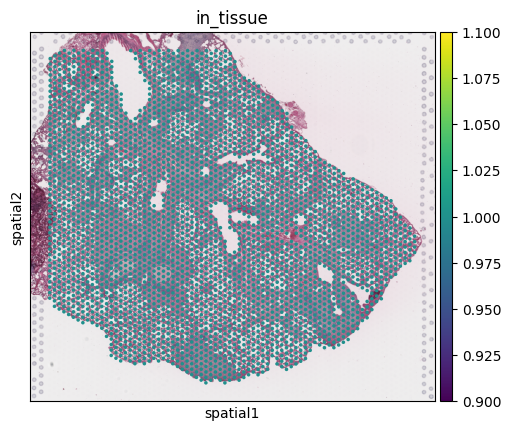

In [16]:
bdata=sc.read_visium(f"{train_path}/C16SPAL/outs")
sc.pl.spatial(bdata,color='in_tissue')
bdata_s= bdata[bdata.obs.index.isin(spot_to_keep)]
sc.pl.spatial(bdata_s,color='in_tissue')

with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]


cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]

# Get the indices of columns with at least 1 count
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep_b = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep_b.append(cols_to_keep[i])

In [17]:
with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]

cols_to_remove = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]
cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]
all_cols = np.arange(bdata_s.X.shape[1])
all_cols = np.delete(all_cols, cols_to_remove)
# rrs_index = bdata_s.var.index.get_loc('rrs')
# cols_to_keep = [col for col in cols_to_keep if col != rrs_index]
# Get the indices of columns with at least 1 count
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep.append(cols_to_keep[i])

# zdata.obs['beads']=(bdata_s.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5
# hdata.obs['beads']=(bdata_s.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5

In [18]:

spdata['Train_3'] = {}
spdata['Train_3']['dataX'] = bdata_s
spdata['Train_3']['ycol'] = final_cols_to_keep
spdata['Train_3']['dataY'] = bdata_s
spdata['Train_3']['xcol'] = all_cols

## Train Slice 4

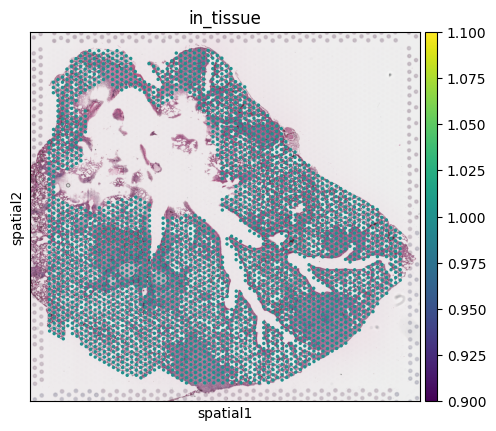

In [19]:
xdata=sc.read_visium("/beegfs/scratch/ric.cirillo.transcriptomics/ric.cirillo.transcriptomics/Progetti_Lore/LORE_probe/old_slice/D16SPA/outs")
sc.pl.spatial(xdata,color='in_tissue')

In [20]:
with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]

cols_to_remove = [xdata.var.index.get_loc(gene) for gene in genes if gene in xdata.var.index]
cols_to_keep = [xdata.var.index.get_loc(gene) for gene in genes if gene in xdata.var.index]
all_cols = np.arange(xdata.X.shape[1])
all_cols = np.delete(all_cols, cols_to_remove)
non_zero_cols = np.where(xdata.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep = []
for i in non_zero_cols:
	gene=xdata.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep.append(cols_to_keep[i])

In [21]:
spdata['Train_4'] = {}
spdata['Train_4']['dataX'] = xdata
spdata['Train_4']['ycol'] = final_cols_to_keep
spdata['Train_4']['dataY'] = xdata
spdata['Train_4']['xcol'] = all_cols

## Train Slice 5 - CTRL

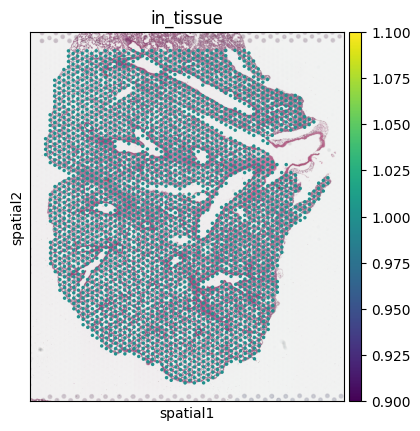

In [22]:
zdata=sc.read_visium(f"{train_path}/V12N16307B1_noair/outs")
sc.pl.spatial(zdata,color='in_tissue')

In [23]:
with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]

cols_to_remove = [zdata.var.index.get_loc(gene) for gene in genes if gene in zdata.var.index]
cols_to_keep = [zdata.var.index.get_loc(gene) for gene in genes if gene in zdata.var.index]
all_cols = np.arange(zdata.X.shape[1])
all_cols = np.delete(all_cols, cols_to_remove)
# Get the indices of columns with at least 1 count
non_zero_cols = np.where(zdata.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep = []
for i in non_zero_cols:
	gene=zdata.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep.append(cols_to_keep[i])

zdata.obs['beads']=(zdata.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5
zdata.obs['beads']=(zdata.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5

In [24]:
spdata['Train_5'] = {}
spdata['Train_5']['dataX'] = zdata
spdata['Train_5']['ycol'] = final_cols_to_keep
spdata['Train_5']['dataY'] = zdata[:,final_cols_to_keep]
spdata['Train_5']['xcol'] = all_cols
spdata['Train_5']['alligned_Y']=zdata[:,final_cols_to_keep]
D=np.zeros([2727,2])
t=zdata.copy()
t=t[:,[1,2]]
t.X=D

spdata['Train_5']['alligned_Y']=t
spdata['Train_5']['overlapping_spot']=np.arange(zdata.X.shape[0]).tolist()

## Train Slice 6 - CTRL

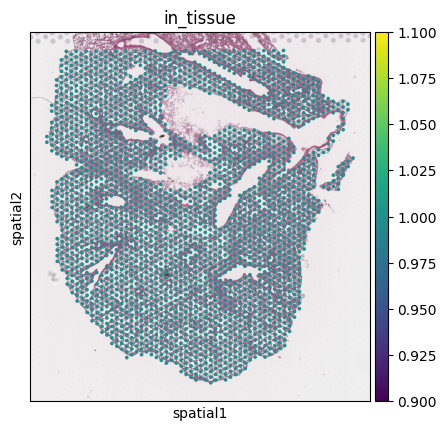

In [25]:
#zdata=sc.read_visium(f"{train_path}/A11SPA/outs")
zdata=sc.read_visium("/beegfs/scratch/ric.cirillo.transcriptomics/ric.cirillo.transcriptomics/Progetti_Lore/LORE_probe/old_slice/A11SPA/outs")

sc.pl.spatial(zdata,color='in_tissue')

In [26]:
with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]

cols_to_remove = [zdata.var.index.get_loc(gene) for gene in genes if gene in zdata.var.index]
cols_to_keep = [zdata.var.index.get_loc(gene) for gene in genes if gene in zdata.var.index]
all_cols = np.arange(zdata.X.shape[1])
all_cols = np.delete(all_cols, cols_to_remove)
rrs_index = zdata.var.index.get_loc('rrs')
cols_to_keep = [col for col in cols_to_keep if col != rrs_index]
# Get the indices of columns with at least 1 count
non_zero_cols = np.where(zdata.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep = []
for i in non_zero_cols:
	gene=zdata.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep.append(cols_to_keep[i])

zdata.obs['beads']=(zdata.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5
zdata.obs['beads']=(zdata.X[:,final_cols_to_keep]).toarray().sum(axis=1)>5

In [27]:
spdata['Train_6'] = {}
spdata['Train_6']['dataX'] = zdata
spdata['Train_6']['ycol'] = final_cols_to_keep
spdata['Train_6']['dataY'] = zdata[:,final_cols_to_keep]
spdata['Train_6']['xcol'] = all_cols
spdata['Train_6']['alligned_Y']=zdata[:,final_cols_to_keep]
D=np.zeros([2452,2])
t=zdata.copy()
t=t[:,[1,2]]
t.X=D

spdata['Train_6']['alligned_Y']=t
spdata['Train_6']['overlapping_spot']=np.arange(zdata.X.shape[0]).tolist()

## External slice

In [28]:
spot_to_keep=pd.read_csv('/beegfs/scratch/ric.cirillo.transcriptomics/ric.cirillo.transcriptomics/Progetti_Lore/LORE_RoughSmooth/jsons/SP-M-MA-F-35/V11D13-010_B1_94RSparenchimaWOairways.json.tab',sep=' ',names=['col','row'])

barcode=pd.read_csv('/idle/ric.cirillo/dimarco.federico/envs/spatial/lib/python/cellranger/barcodes/visium-v2_coordinates.txt',sep='\t',names=['barcode','col','row'])

spot_to_keep=spot_to_keep.merge(barcode,how='inner',on=['col','row'])['barcode']

spot_to_keep=spot_to_keep + '-1'

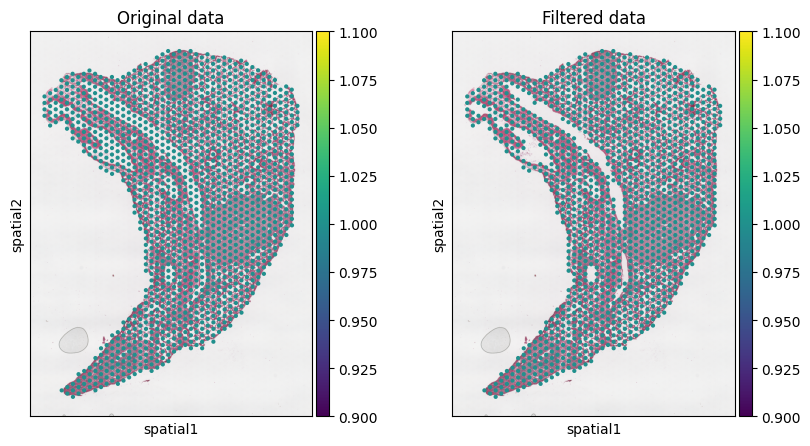

In [29]:
bdata=sc.read_visium("/idle/ric.cirillo.transcriptomics/spaceranger_dir/B1_V11D13-010/outs")

fig,ax=plt.subplots(1,2,figsize=(10,5))

sc.pl.spatial(bdata,color='in_tissue',ax=ax[0],show=False,title='Original data')
bdata_s= bdata[bdata.obs.index.isin(spot_to_keep)]
sc.pl.spatial(bdata_s,color='in_tissue',ax=ax[1],show=False,title='Filtered data')
plt.show()

with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]


cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]

# Get the indices of columns with at least 1 count
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep_b = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep_b.append(cols_to_keep[i])

In [30]:
with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
	genes = [line.strip() for line in f]

cols_to_remove = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]
cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]
all_cols = np.arange(bdata_s.X.shape[1])
all_cols = np.delete(all_cols, cols_to_remove)
rrs_index = bdata_s.var.index.get_loc('rrs')
cols_to_keep = [col for col in cols_to_keep if col != rrs_index]
# Get the indices of columns with at least 1 count
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep.append(cols_to_keep[i])

In [31]:
key='Ext_1'
spdata[key] = {}
spdata[key]['dataX'] = bdata_s
spdata[key]['ycol'] = final_cols_to_keep
spdata[key]['dataY'] = bdata_s
spdata[key]['xcol'] = all_cols

## Pathogen only slices 1

In [32]:
spot_to_keep=pd.read_csv('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/analysis/subs/B1_6SPA/V13J17-404-B1_noair.json.tab',sep=' ',names=['col','row'])

barcode=pd.read_csv('/idle/ric.cirillo/dimarco.federico/envs/spatial/lib/python/cellranger/barcodes/visium-v2_coordinates.txt',sep='\t',names=['barcode','col','row'])

spot_to_keep=spot_to_keep.merge(barcode,how='inner',on=['col','row'])['barcode']

spot_to_keep=spot_to_keep + '-1'

print(spot_to_keep)

0       GTGTGAGCCGAGGTGC-1
1       GGGAACCACCTGTTTC-1
2       GTTCGTTGCGGACCAG-1
3       TGAGGTTGATCCCAAG-1
4       GATGCCACACTACAGC-1
               ...        
3515    CGAAGATCAGTTTCAT-1
3516    ACGCCACTCGAAACAG-1
3517    CTTAGATGTTTCATCC-1
3518    TAAATTGTGGGTAAAG-1
3519    GCGTCGTAACATGGTC-1
Name: barcode, Length: 3520, dtype: object


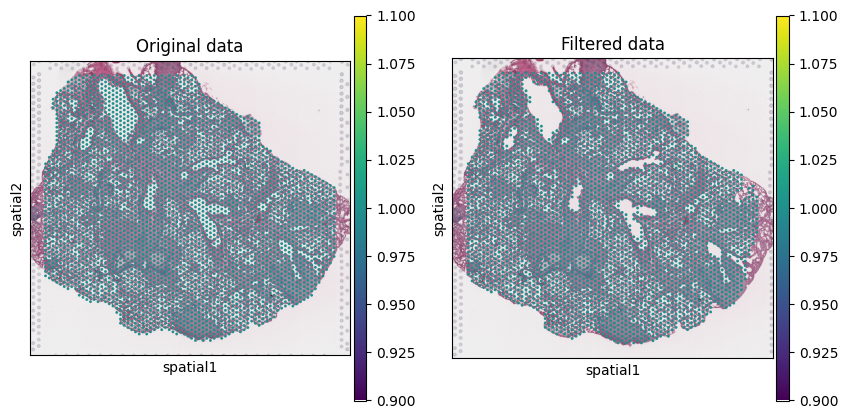

In [35]:
bdata=sc.read_visium(f"{train_path}/B16SPA/outs")
fig,ax=plt.subplots(1,2,figsize=(10,5))
sc.pl.spatial(bdata,color='in_tissue',ax=ax[0],show=False,title='Original data')
bdata_s= bdata[bdata.obs.index.isin(spot_to_keep)]
sc.pl.spatial(bdata_s,color='in_tissue',ax=ax[1],show=False,title='Filtered data')
plt.show()

with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]


cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]

# Get the indices of columns with at least 1 count
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep_b = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep_b.append(cols_to_keep[i])

In [36]:
spdata['GT_1']={}
spdata['GT_1']['dataX'] = bdata_s
spdata['GT_1']['ycol'] = final_cols_to_keep_b

## Pathogen only slices 2

In [37]:
spot_to_keep=pd.read_csv('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/analysis/subs/D1_6SPAL/V13J17-404-D1_noair.json.tab',sep=' ',names=['col','row'])

barcode=pd.read_csv('/idle/ric.cirillo/dimarco.federico/envs/spatial/lib/python/cellranger/barcodes/visium-v2_coordinates.txt',sep='\t',names=['barcode','col','row'])

spot_to_keep=spot_to_keep.merge(barcode,how='inner',on=['col','row'])['barcode']

spot_to_keep=spot_to_keep + '-1'

print(spot_to_keep)

0       GCACTCCCACAGTCCC-1
1       CAGGATCCGCCCGACC-1
2       GGTTGTATCGTGAAAT-1
3       ATGGTGCTCAAAGCCA-1
4       CAAATGCGGAGTGTTC-1
               ...        
3523    CCCTGGGAGGGATCCT-1
3524    TAGTAGTTGCCGGACA-1
3525    GCCCTAAGTGCAGGAT-1
3526    ACTTGGGCTTTCGCCA-1
3527    CATGATACGGTGAAAC-1
Name: barcode, Length: 3528, dtype: object


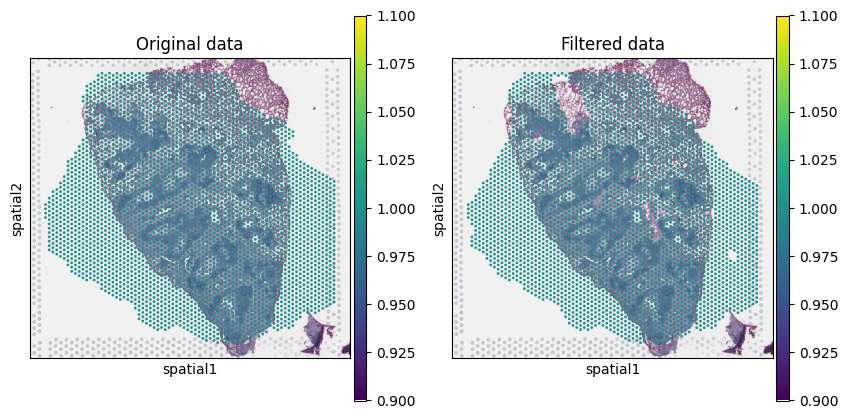

In [40]:
bdata=sc.read_visium(f"{train_path}/D16SPAL/outs")
fig,ax=plt.subplots(1,2,figsize=(10,5))
sc.pl.spatial(bdata,color='in_tissue',ax=ax[0],show=False,title='Original data')
bdata_s= bdata[bdata.obs.index.isin(spot_to_keep)]
sc.pl.spatial(bdata_s,color='in_tissue',ax=ax[1],show=False,title='Filtered data')

with open('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/MAB_list.scanpy.txt', 'r') as f:
    genes = [line.strip() for line in f]


cols_to_keep = [bdata_s.var.index.get_loc(gene) for gene in genes if gene in bdata_s.var.index]

# Get the indices of columns with at least 1 count
non_zero_cols = np.where(bdata_s.X[:,cols_to_keep].sum(axis=0) > 0)[1]

gene_list=[]
final_cols_to_keep_b = []
for i in non_zero_cols:
	gene=bdata_s.var.index[cols_to_keep[i]]
	gene_list.append(gene)
	final_cols_to_keep_b.append(cols_to_keep[i])

In [41]:
spdata['GT_2']={}
spdata['GT_2']['dataX'] = bdata_s
spdata['GT_2']['ycol'] = final_cols_to_keep_b

In [42]:
index='GT_2'
print(f"Index: {index}")
anchors=pd.read_csv('/beegfs/scratch/ric.cirillo/dimarco.federico/LORE_probe/SPATIAL/analysis/subs/D1_6SPAL/V13J17-404-D1_anchors.json.tab',sep=' ',names=['col','row','type'])

barcode=pd.read_csv('/idle/ric.cirillo/dimarco.federico/envs/spatial/lib/python/cellranger/barcodes/visium-v2_coordinates.txt',sep='\t',names=['barcode','col','row'])

anchors=anchors.merge(barcode,how='inner',on=['col','row'])

anchors['barcode']=anchors['barcode'] + '-1'

anchors.set_index('barcode', inplace=True)

tt=spdata[index]['dataX'].obs.merge(anchors,how='left',left_index=True,right_index=True)['type']
spdata[index]['dataX'].obs['type']=tt.fillna('no_anchors')


Index: GT_2


# Load anchors

In [44]:
master_key=pd.read_csv('/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/GROUND_TRUTH/DATA/MASTER_KEY.csv')
master_key.set_index('Dataset',inplace=True)

In [45]:
for index, row in master_key.iterrows():
	print(f"Index: {index}")
	anchors=pd.read_csv(row['Anchors'],sep=' ',names=['col','row','type'])
	
	barcode=pd.read_csv('/idle/ric.cirillo/dimarco.federico/envs/spatial/lib/python/cellranger/barcodes/visium-v2_coordinates.txt',sep='\t',names=['barcode','col','row'])

	anchors=anchors.merge(barcode,how='inner',on=['col','row'])

	anchors['barcode']=anchors['barcode'] + '-1'

	anchors.set_index('barcode', inplace=True)

	tt=spdata[index]['dataX'].obs.merge(anchors,how='left',left_index=True,right_index=True)['type']
	spdata[index]['dataX'].obs['type']=tt.fillna('no_anchors')


Index: Train_1
Index: Train_2
Index: Train_3
Index: Train_4
Index: GT_1


# Log-normalize data

In [46]:
HP_keys=['Train_1','Train_2','Train_3','Train_4','Train_5','Train_6','Ext_1']

In [50]:
for key in HP_keys:
#for key in kong_keys:
#for key in spdata.keys():
	spdata[key]['dataXNorm']=spatial.LogNormSpData(spdata,key)
	print(f'{key} normalized')

Train_1 normalized
Train_2 normalized
Train_3 normalized
Train_4 normalized
Train_5 normalized
Train_6 normalized
Ext_1 normalized


## Project Bacterial data

### Define z stack level

In [51]:
spdata['Train_1']['zlevel']=1
spdata['Train_2']['zlevel']=3
spdata['Train_3']['zlevel']=5
spdata['Train_4']['zlevel']=2

In [55]:
train_keys=['Train_1','Train_2','Train_3','Train_4']
for key in train_keys:
	number = int(key.split('_')[1])
	if number > 4:
		continue
	for z in [0,0.1,0.5,1]:
		for z0 in [0,1]:
			dd='Alligned_GT12_x' + str(z0) + '_z' + str(z) +'_Y'
			print(f'Projecting GT to {key} with z={z} ----> {dd}')
			x,f=spatial.ComputeGTonZaxis(spdata,key,GTs=['GT_1','GT_2'],zaxis=[4,6],z0possition=spdata[key]['zlevel'],zcoeff=z,z0coeff=z0)
			spdata[key][dd]=x
			spdata[key]['GT12_overlapSpots']=f
			dd='Alligned_GT1_x' + str(z0) + '_z' + str(z) +'_Y'
			print(f'Projecting GT1 to {key} with z={z} ----> {dd}')
			x,f=spatial.ComputeGTonZaxis(spdata,key,GTs=['GT_1'],zaxis=[4],z0possition=spdata[key]['zlevel'],zcoeff=z,z0coeff=z0)
			spdata[key][dd]=x
			spdata[key]['GT1_overlapSpots']=f
			dd='Alligned_GT2_x' + str(z0) + '_z' + str(z) +'_Y'
			print(f'Projecting GT2 to {key} with z={z} ----> {dd}')
			x,f=spatial.ComputeGTonZaxis(spdata,key,GTs=['GT_2'],zaxis=[6],z0possition=spdata[key]['zlevel'],zcoeff=z,z0coeff=z0)
			spdata[key][dd]=x
			spdata[key]['GT2_overlapSpots']=f

Projecting GT to Train_1 with z=0 ----> Alligned_GT12_x0_z0_Y
GT 0 Z score: 1.0
GT 1 Z score: 1.0
Projecting GT1 to Train_1 with z=0 ----> Alligned_GT1_x0_z0_Y
GT 0 Z score: 1.0
Projecting GT2 to Train_1 with z=0 ----> Alligned_GT2_x0_z0_Y
GT 0 Z score: 1.0
Projecting GT to Train_1 with z=0 ----> Alligned_GT12_x1_z0_Y
GT 0 Z score: 1.0
GT 1 Z score: 1.0
Projecting GT1 to Train_1 with z=0 ----> Alligned_GT1_x1_z0_Y
GT 0 Z score: 1.0
Projecting GT2 to Train_1 with z=0 ----> Alligned_GT2_x1_z0_Y
GT 0 Z score: 1.0
Projecting GT to Train_1 with z=0.1 ----> Alligned_GT12_x0_z0.1_Y
GT 0 Z score: 0.7408182206817179
GT 1 Z score: 0.6065306597126334
Projecting GT1 to Train_1 with z=0.1 ----> Alligned_GT1_x0_z0.1_Y
GT 0 Z score: 0.7408182206817179
Projecting GT2 to Train_1 with z=0.1 ----> Alligned_GT2_x0_z0.1_Y
GT 0 Z score: 0.6065306597126334
Projecting GT to Train_1 with z=0.1 ----> Alligned_GT12_x1_z0.1_Y
GT 0 Z score: 0.7408182206817179
GT 1 Z score: 0.6065306597126334
Projecting GT1 to Trai

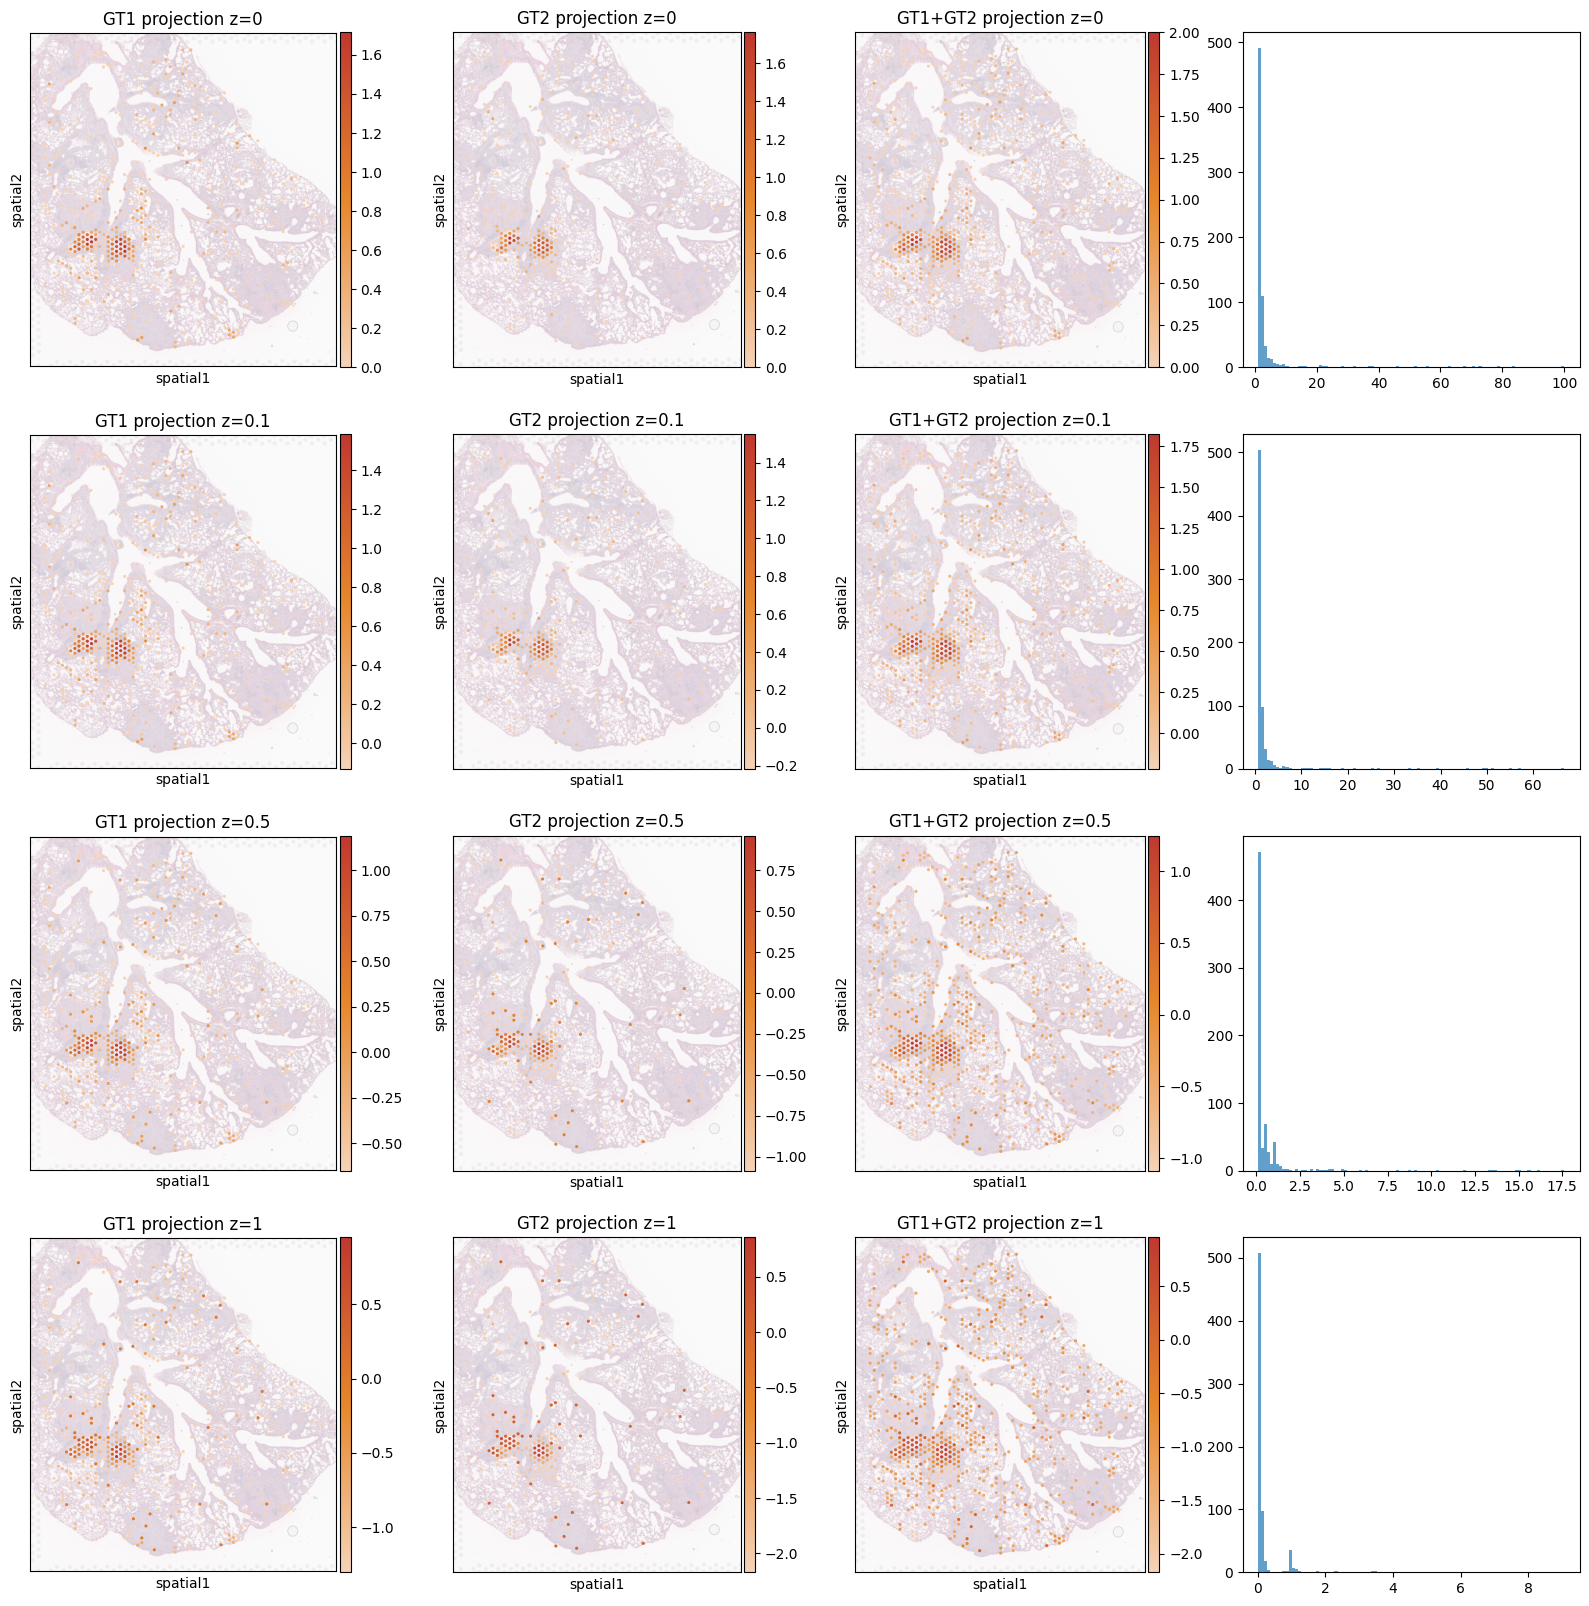

In [60]:
fig,ax=plt.subplots(4,4,figsize=(20,20))


RAW_COLORS = ['#f5d3b8', '#E7872B', '#C03830']
RAW_CMAP = LinearSegmentedColormap.from_list('raw_bact', RAW_COLORS, N=256)
for i,z in enumerate([0,0.1,0.5,1]):
	dd='Alligned_GT1_x1_z' + str(z) + '_Y'
	d=spdata['Train_1'][dd].copy()
	d.obs['Bacterial_signal']=np.log10(np.sum(d.X.toarray(),axis=1))
	sc.pl.spatial(d, color='Bacterial_signal', ax=ax[i,0], show=False,cmap=RAW_CMAP,alpha_img=0.3)

	dd='Alligned_GT2_x1_z' + str(z) + '_Y'
	d=spdata['Train_1'][dd].copy()
	d.obs['Bacterial_signal']=np.log10(np.sum(d.X.toarray(),axis=1))
	sc.pl.spatial(d, color='Bacterial_signal', ax=ax[i,1], show=False,cmap=RAW_CMAP,alpha_img=0.3)

	dd='Alligned_GT12_x1_z' + str(z) + '_Y'
	d=spdata['Train_1'][dd].copy()
	d.obs['Bacterial_signal']=np.log10(np.sum(d.X.toarray(),axis=1))
	sc.pl.spatial(d, color='Bacterial_signal', ax=ax[i,2], show=False,cmap=RAW_CMAP,alpha_img=0.3)
	ax[i,0].set_title(f'GT1 projection z={z}')
	ax[i,1].set_title(f'GT2 projection z={z}')
	ax[i,2].set_title(f'GT1+GT2 projection z={z}')

	ax[i,3].hist(np.sum(d.X.toarray(),axis=1)[np.sum(d.X.toarray(),axis=1)>0],bins=100,alpha=0.7)





# Smoothing

In [62]:

for key in HP_keys:
	number = int(key.split('_')[1])
	print(f'Computing Local D for {key} - Norm')
	spdata[key]['local_D_Xnorm_d200']=spatial.GetLocalPCADistance(spdata,key,'dataXNorm',Dist=200)
	print(f'Computing Global D for {key} - Norm')
	spdata[key]['global_D_Xnorm_d200']=spatial.GetGlobalPCADistance(spdata,key,'dataXNorm',Dist=200)
	print(f'Computing Local D for {key} - RAW')
	spdata[key]['local_D_XRaw_d200']=spatial.GetLocalPCADistance(spdata,key,'dataX',Dist=200)
	print(f'Computing Global D for {key} -RAW')
	spdata[key]['global_D_XRaw_d200']=spatial.GetGlobalPCADistance(spdata,key,'dataX',Dist=200)
	

Computing Local D for Train_1 - Norm


KeyboardInterrupt: 

In [64]:
for key in HP_keys:
	number = int(key.split('_')[1])
	for z in [0,0.1,0.5,1]:
		for z0 in [0,1]:
			for GT in ['GT1','GT2','GT12']:
				dd='Alligned_'+str(GT) +'_x' + str(z0) + '_z' + str(z) + '_Y'
				yy="Y_" + str(GT) + "_x" + str(z0) +"_z" +str(z)+ '_'
				print(f"Processing {key} - {z0} - {z} - {GT}")
				if number < 5:
					gg=str(GT)+"_overlapSpots"
					print(f'Processing {key} - mean - Xnorm')
					yyy=yy+'MeanXnorm'
					if yyy not in spdata[key]:
						spdata[key][yyy],_=spatial.Smooth(spdata,key,dd,'dataXNorm',overlap=gg,mode='Mean',Dist=200)
					else:
						print(f'{key} - {yyy} already computed')

					print(f'Processing {key} - local - Xnorm')
					yyy=yy+'LocalXnorm'
					if yyy not in spdata[key]:
						spdata[key][yyy],_=spatial.Smooth(spdata,key,dd,'dataXNorm',overlap=gg,mode='Local',Dist=200,D='local_D_Xnorm_d200')
					else:
						print(f'{key} - {yyy} already computed')
					
					print(f'Processing {key} - global - Xnorm')
					yyy=yy+'GlobalXnorm'
					if yyy not in spdata[key]:
						spdata[key][yyy],_=spatial.Smooth(spdata,key,dd,'dataXNorm',overlap=gg,mode='Global',Dist=200,D='global_D_Xnorm_d200')
					else:
						print(f'{key} - {yyy} already computed')
					
					print(f'Processing {key} - mean - XRaw')
					yyy=yy+'MeanXRaw'
					if yyy not in spdata[key]:
						spdata[key][yyy],_=spatial.Smooth(spdata,key,dd,'dataX',overlap=gg,mode='Mean',Dist=200)
					else:
						print(f'{key} - {yyy} already computed')
					
					print(f'Processing {key} - local - XRaw')
					yyy=yy+'LocalXRaw'
					if yyy not in spdata[key]:
						spdata[key][yyy],_=spatial.Smooth(spdata,key,dd,'dataX',overlap=gg,mode='Local',Dist=200,D='local_D_XRaw_d200')
					else:
						print(f'{key} - {yyy} already computed')
					
					print(f'Processing {key} - global - XRaw')
					yyy=yy+'GlobalXRaw'
					if yyy not in spdata[key]:
						spdata[key][yyy],_=spatial.Smooth(spdata,key,dd,'dataX',overlap=gg,mode='Global',Dist=200,D='global_D_XRaw_d200')
					else:
						print(f'{key} - {yyy} already computed')
					
					print(f'Processed {key} - NoSmooth')
					yyy=yy+'NoSmooth'
					spdata[key][yyy]=spdata[key][dd]
				else:
					print(f'No data to smooth (NG controls) for {key}')
					yyy=yy+'MeanXnorm'
					spdata[key][yyy]=spdata[key]['alligned_Y']
					yyy=yy+'LocalXnorm'
					spdata[key][yyy]=spdata[key]['alligned_Y']
					yyy=yy+'GlobalXnorm'
					spdata[key][yyy]=spdata[key]['alligned_Y']
					yyy=yy+'MeanXRaw'
					spdata[key][yyy]=spdata[key]['alligned_Y']
					yyy=yy+'LocalXRaw'
					spdata[key][yyy]=spdata[key]['alligned_Y']
					yyy=yy+'GlobalXRaw'
					spdata[key][yyy]=spdata[key]['alligned_Y']
					yyy=yy+'NoSmooth'
					spdata[key][yyy]=spdata[key]['alligned_Y']



Processing Train_1 - 0 - 0 - GT1
Processing Train_1 - mean - Xnorm
Train_1 - Y_GT1_x0_z0_MeanXnorm already computed
Processing Train_1 - local - Xnorm


KeyboardInterrupt: 

In [67]:
dump(spdata, 'data/SPDATA.h5ad')

['data/SPDATA.h5ad']